In [1]:
!git clone https://github.com/sandhyaasriram/iv-infil-monitoring.git

Cloning into 'iv-infil-monitoring'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 33 (delta 12), reused 27 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 15.97 KiB | 340.00 KiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
%cd iv-infil-monitoring/

/content/iv-infil-monitoring


In [3]:
from generate_dataset import build_labeled_dataframe

df = build_labeled_dataframe(n_per_class=50)   # 50 trials per severity class
df.to_csv("synthetic_iv_infiltration_dataset.csv", index=False)
df.groupby(["severity", "condition"]).size()

severity  condition       
early     missing_pressure    18000
          missing_temp        18000
          noisy_pressure      18000
          noisy_temp          18000
          normal              18000
moderate  missing_pressure    18000
          missing_temp        18000
          noisy_pressure      18000
          noisy_temp          18000
          normal              18000
none      missing_pressure    18000
          missing_temp        18000
          noisy_pressure      18000
          noisy_temp          18000
          normal              18000
severe    missing_pressure    18000
          missing_temp        18000
          noisy_pressure      18000
          noisy_temp          18000
          normal              18000
dtype: int64

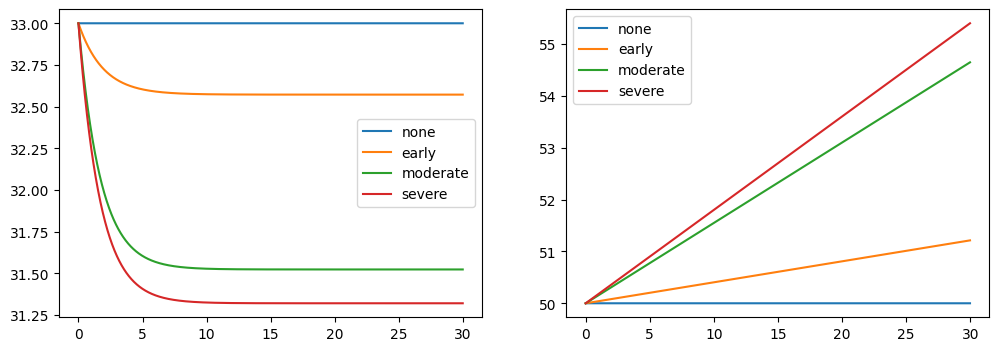

In [4]:
import matplotlib.pyplot as plt
from simulator.scenarios import generate_trial
import numpy as np

rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for sev in ['none','early','moderate','severe']:
    trial = generate_trial(sev, duration_s=1800, dt=1.0, rng=rng)
    axes[0].plot(trial['time']/60, trial['temperature_ideal'], label=sev)
    axes[1].plot(trial['time']/60, trial['pressure_ideal'], label=sev)
axes[0].legend(); axes[1].legend()
plt.show()

In [5]:
import numpy as np
import pandas as pd

WINDOW_S = 25  # start with 25s, matching the 2021 study's finding — you'll sweep this later

def extract_window_features(group):
    feats, labels, trial_ids, conditions = [], [], [], []
    temp = group['temperature_c'].values
    press = group['pressure_adc'].values
    lab = group['label'].values          # <-- NEW: per-row labels, not a single trial-level value
    n = len(group)

    for start in range(0, n - WINDOW_S, WINDOW_S):
        t_win = temp[start:start+WINDOW_S]
        p_win = press[start:start+WINDOW_S]
        l_win = lab[start:start+WINDOW_S]

        # NaN-safe stats (missing-sensor condition produces all-NaN windows)
        def safe_stats(x, prefix):
            if np.all(np.isnan(x)):
                return {f'{prefix}_mean': np.nan, f'{prefix}_std': np.nan,
                        f'{prefix}_slope': np.nan, f'{prefix}_min': np.nan,
                        f'{prefix}_max': np.nan}
            return {
                f'{prefix}_mean': np.nanmean(x),
                f'{prefix}_std': np.nanstd(x),
                f'{prefix}_slope': np.polyfit(np.arange(len(x)), np.nan_to_num(x, nan=np.nanmean(x)), 1)[0],
                f'{prefix}_min': np.nanmin(x),
                f'{prefix}_max': np.nanmax(x),
            }

        row = {}
        row.update(safe_stats(t_win, 'temp'))
        row.update(safe_stats(p_win, 'press'))
        row['sensor_missing_temp'] = int(np.all(np.isnan(t_win)))
        row['sensor_missing_press'] = int(np.all(np.isnan(p_win)))

        feats.append(row)
        labels.append(np.bincount(l_win).argmax())
        trial_ids.append(group['trial_id'].iloc[0])
        conditions.append(group['condition'].iloc[0])

    out = pd.DataFrame(feats)
    out['label'] = labels
    out['trial_id'] = trial_ids
    out['condition'] = conditions
    return out

feature_dfs = [extract_window_features(g) for _, g in df.groupby('trial_id')]
features = pd.concat(feature_dfs, ignore_index=True)
print(features.shape)
features.head()

(14200, 15)


,temp_mean,temp_std,temp_slope,temp_min,temp_max,press_mean,press_std,press_slope,press_min,press_max,sensor_missing_temp,sensor_missing_press,label,trial_id,condition
0,32.9700,0.138203,-0.003702,32.6875,33.2500,49.48,2.264862,-0.031538,45.0,54.0,0,0,0,0,normal
1,32.9775,0.147775,0.000529,32.6875,33.3125,49.96,3.155693,-0.106154,45.0,58.0,0,0,0,0,normal
2,33.0225,0.126095,0.004663,32.8125,33.3125,49.88,3.140955,0.033077,44.0,55.0,0,0,0,0,normal
3,32.9550,0.195672,-0.002163,32.5625,33.3750,51.04,3.091666,0.019231,45.0,57.0,0,0,0,0,normal
4,32.9550,0.139777,-0.007308,32.6875,33.2500,50.20,2.898275,-0.016154,41.0,55.0,0,0,0,0,normal


In [6]:
import numpy as np
import pandas as pd

WINDOW_S = 25  # start with 25s, matching the 2021 study's finding

def extract_window_features(group):
    feats, labels, trial_ids, conditions = [], [], [], []
    temp = group['temperature_c'].values
    press = group['pressure_adc'].values
    lab = group['label'].values          # <-- NEW: per-row labels, not a single trial-level value
    n = len(group)

    for start in range(0, n - WINDOW_S, WINDOW_S):
        t_win = temp[start:start+WINDOW_S]
        p_win = press[start:start+WINDOW_S]
        l_win = lab[start:start+WINDOW_S]

        # NaN-safe stats (missing-sensor condition produces all-NaN windows)
        def safe_stats(x, prefix):
            if np.all(np.isnan(x)):
                return {f'{prefix}_mean': np.nan, f'{prefix}_std': np.nan,
                        f'{prefix}_slope': np.nan, f'{prefix}_min': np.nan,
                        f'{prefix}_max': np.nan}
            return {
                f'{prefix}_mean': np.nanmean(x),
                f'{prefix}_std': np.nanstd(x),
                f'{prefix}_slope': np.polyfit(np.arange(len(x)), np.nan_to_num(x, nan=np.nanmean(x)), 1)[0],
                f'{prefix}_min': np.nanmin(x),
                f'{prefix}_max': np.nanmax(x),
            }

        row = {}
        row.update(safe_stats(t_win, 'temp'))
        row.update(safe_stats(p_win, 'press'))
        row['sensor_missing_temp'] = int(np.all(np.isnan(t_win)))
        row['sensor_missing_press'] = int(np.all(np.isnan(p_win)))

        feats.append(row)
        labels.append(np.bincount(l_win).argmax())
        trial_ids.append(group['trial_id'].iloc[0])
        conditions.append(group['condition'].iloc[0])

    out = pd.DataFrame(feats)
    out['label'] = labels
    out['trial_id'] = trial_ids
    out['condition'] = conditions
    return out

feature_dfs = [extract_window_features(g) for _, g in df.groupby('trial_id')]
features = pd.concat(feature_dfs, ignore_index=True)
print(features.shape)
features.head()

(14200, 15)


,temp_mean,temp_std,temp_slope,temp_min,temp_max,press_mean,press_std,press_slope,press_min,press_max,sensor_missing_temp,sensor_missing_press,label,trial_id,condition
0,32.9700,0.138203,-0.003702,32.6875,33.2500,49.48,2.264862,-0.031538,45.0,54.0,0,0,0,0,normal
1,32.9775,0.147775,0.000529,32.6875,33.3125,49.96,3.155693,-0.106154,45.0,58.0,0,0,0,0,normal
2,33.0225,0.126095,0.004663,32.8125,33.3125,49.88,3.140955,0.033077,44.0,55.0,0,0,0,0,normal
3,32.9550,0.195672,-0.002163,32.5625,33.3750,51.04,3.091666,0.019231,45.0,57.0,0,0,0,0,normal
4,32.9550,0.139777,-0.007308,32.6875,33.2500,50.20,2.898275,-0.016154,41.0,55.0,0,0,0,0,normal


In [7]:
from sklearn.model_selection import train_test_split

unique_trials = features['trial_id'].unique()
train_trials, test_trials = train_test_split(unique_trials, test_size=0.25, random_state=42)

train_df = features[features['trial_id'].isin(train_trials)]
test_df = features[features['trial_id'].isin(test_trials)]

feature_cols = [c for c in features.columns if c not in ['label', 'trial_id', 'condition']]

X_train, y_train = train_df[feature_cols], train_df['label']
X_test, y_test = test_df[feature_cols], test_df['label']

print(f"Train: {len(train_trials)} trials, {len(X_train)} windows")
print(f"Test:  {len(test_trials)} trials, {len(X_test)} windows")

Train: 150 trials, 10650 windows
Test:  50 trials, 3550 windows


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# imputer handles the missing-sensor windows (NaN features) instead of crashing on them
pipe_logreg = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, multi_class='multinomial')),
])

pipe_logreg.fit(X_train, y_train)
y_pred = pipe_logreg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['none','early','moderate','severe']))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

        none       0.74      0.85      0.79      1269
       early       0.69      0.63      0.66      1381
    moderate       0.71      0.67      0.69       690
      severe       0.77      0.73      0.75       210

    accuracy                           0.72      3550
   macro avg       0.73      0.72      0.72      3550
weighted avg       0.72      0.72      0.72      3550

Macro F1: 0.7201285314348198


In [9]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)),
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['none','early','moderate','severe']))

              precision    recall  f1-score   support

        none       0.86      0.74      0.79      1269
       early       0.72      0.71      0.71      1381
    moderate       0.64      0.83      0.72       690
      severe       0.72      0.77      0.74       210

    accuracy                           0.74      3550
   macro avg       0.74      0.76      0.74      3550
weighted avg       0.76      0.74      0.75      3550



In [10]:
results = []

def evaluate_and_log(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    results.append({
        'model': name,
        'accuracy': (y_pred == y_test).mean(),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'early_recall': classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
    })

evaluate_and_log('LogisticRegression', pipe_logreg, X_test, y_test)
evaluate_and_log('RandomForest', pipe_rf, X_test, y_test)
pd.DataFrame(results)

,model,accuracy,macro_f1,early_recall
0,LogisticRegression,0.718592,0.720129,0.627082
1,RandomForest,0.744225,0.743916,0.707458


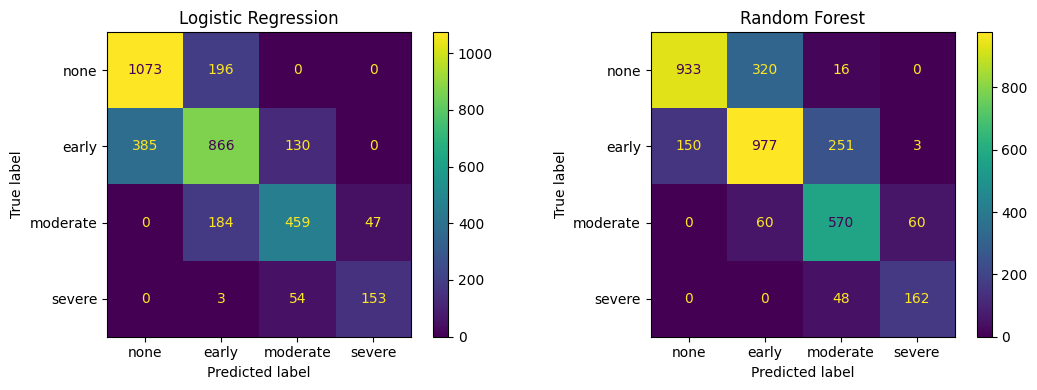

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['none','early','moderate','severe'], ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['none','early','moderate','severe'], ax=axes[1])
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.show()

In [12]:
temp_cols = [c for c in feature_cols if c.startswith('temp_')]
press_cols = [c for c in feature_cols if c.startswith('press_')]

ablation_results = {}
for name, cols in [('temp_only', temp_cols), ('pressure_only', press_cols), ('fused', feature_cols)]:
    pipe = Pipeline([('impute', SimpleImputer(strategy='mean')),
                      ('clf', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))])
    pipe.fit(X_train[cols], y_train)
    pred = pipe.predict(X_test[cols])
    ablation_results[name] = f1_score(y_test, pred, average='macro')

pd.Series(ablation_results, name='macro_f1')

,macro_f1
temp_only,0.599709
pressure_only,0.594360
fused,0.748512


In [13]:
robustness_scores = {}
for cond in test_df['condition'].unique():
    mask = test_df['condition'] == cond
    X_c, y_c = X_test[mask], y_test[mask]
    pred_c = pipe_rf.predict(X_c)
    robustness_scores[cond] = f1_score(y_c, pred_c, average='macro')

pd.Series(robustness_scores, name='macro_f1').sort_values()

,macro_f1
missing_temp,0.571536
noisy_pressure,0.577205
missing_pressure,0.598410
normal,0.812990
noisy_temp,0.823143


In [14]:
window_sweep_results = {}
for w in [10, 25, 50, 100]:
    globals()['WINDOW_S'] = w
    feats_w = pd.concat([extract_window_features(g) for _, g in df.groupby('trial_id')], ignore_index=True)
    train_w = feats_w[feats_w['trial_id'].isin(train_trials)]
    test_w = feats_w[feats_w['trial_id'].isin(test_trials)]
    fc = [c for c in feats_w.columns if c not in ['label','trial_id','condition']]

    pipe = Pipeline([('impute', SimpleImputer(strategy='mean')),
                      ('clf', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))])
    pipe.fit(train_w[fc], train_w['label'])
    pred = pipe.predict(test_w[fc])
    window_sweep_results[w] = f1_score(test_w['label'], pred, average='macro')

pd.Series(window_sweep_results, name='macro_f1')

,macro_f1
10,0.702774
25,0.748512
50,0.788942
100,0.831247


In [15]:
import numpy as np
cm = confusion_matrix(y_test, y_pred_rf)
print(pd.DataFrame(cm, index=['true_none','true_early','true_moderate','true_severe'],
                    columns=['pred_none','pred_early','pred_moderate','pred_severe']))

               pred_none  pred_early  pred_moderate  pred_severe
true_none            933         320             16            0
true_early           150         977            251            3
true_moderate          0          60            570           60
true_severe            0           0             48          162
